In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Data cleaning and pre-processing****

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dibyabhowmik/app-insights/Ap insights.csv


In [7]:
df = pd.read_csv('/kaggle/input/datasets/dibyabhowmik/app-insights/Ap insights.csv')

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


 Initial Data Inspection****

In [8]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (10841, 13)

Column names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Data types:
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Handling Missing Values

In [9]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

display(missing_summary)

,Missing Values,Missing Percentage
Rating,1474,13.596532
Type,1,0.009224
Content Rating,1,0.009224
Current Ver,8,0.073794
Android Ver,3,0.027673


In [13]:
# Fill missing categorical values
categorical_columns = ['Type', 'Content Rating', 'Current Ver', 'Android Ver']

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

In [10]:
print(df.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64


In [14]:
missing_rating_pct = df['Rating'].isnull().mean() * 100

print(f"Missing Rating values: {df['Rating'].isnull().sum()}")
print(f"Missing Rating percentage: {missing_rating_pct:.2f}%")

Missing Rating values: 1474
Missing Rating percentage: 13.60%


In [12]:
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64


Converting Data Types****

In [15]:
#Reviews
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
print(df['Reviews'].dtype)

float64


Convert Size to MB

In [16]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size).strip()
    
    if size == 'Varies with device':
        return np.nan
    
    if size.endswith('M'):
        return float(size[:-1])
    
    elif size.endswith('k'):
        return float(size[:-1]) / 1024
    
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

In [17]:
display(df[['Size', 'Size_MB']].head(10))

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


Removing Duplicate Entries****

In [18]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 483


In [19]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10358, 14)


Standardizing texts ****

In [20]:
text_columns = [
    'App',
    'Category',
    'Type',
    'Content Rating',
    'Genres',
    'Current Ver',
    'Android Ver'
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [21]:
df['Type'] = df['Type'].str.title()

In [22]:
print("Category values:")
print(df['Category'].unique())

print("\nGenres values:")
print(df['Genres'].unique()[:20])

print("\nType values:")
print(df['Type'].unique())

Category values:
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

Genres values:
['Art & Design' 'Art & Design;Pretend Play' 'Art & Design;Creativity'
 'Art & Design;Action & Adventure' 'Auto & Vehicles' 'Beauty'
 'Books & Reference' 'Business' 'Comics' 'Comics;Creativity'
 'Communication' 'Dating' 'Education;Education' 'Education'
 'Education;Creativity' 'Education;Music & Video'
 'Education;Action & Adventure' 'Education;Pretend Play'
 'Education;Brain Games' 'Entertainment']

Type values:
['Free' 'Paid' 'Unknown' '0']


Convert Last Updated to Datetime****

In [28]:
df['Last Updated'] = pd.to_datetime(
    df['Last Updated'],
    errors='coerce'
)

In [24]:
#Check
print(df['Last Updated'].dtype)

display(df[['Last Updated']].head())

object


,Last Updated
0,"January 7, 2018"
1,"January 15, 2018"
2,"August 1, 2018"
3,"June 8, 2018"
4,"June 20, 2018"


In [27]:
df['Last Updated'] = pd.to_datetime(
    df['Last Updated'],
    errors='coerce'
)

In [28]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Extract month
df['Update Month'] = df['Last Updated'].dt.month

FInal cleaned dataset ****

In [29]:
df_clean = df.copy()

print("Cleaned dataset shape:", df_clean.shape)
display(df_clean.head())

Cleaned dataset shape: (10358, 15)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Update Month
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,1.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,1.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,8.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,6.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,6.0


Basic Level****

Question1

In [30]:
average_rating = df['Rating'].mean()

print(f"Average app rating: {average_rating:.2f}")

Average app rating: 4.19


Question 2

In [31]:
unique_categories = df['Category'].nunique()

print(f"Number of unique app categories: {unique_categories}")

Number of unique app categories: 34


Question 3

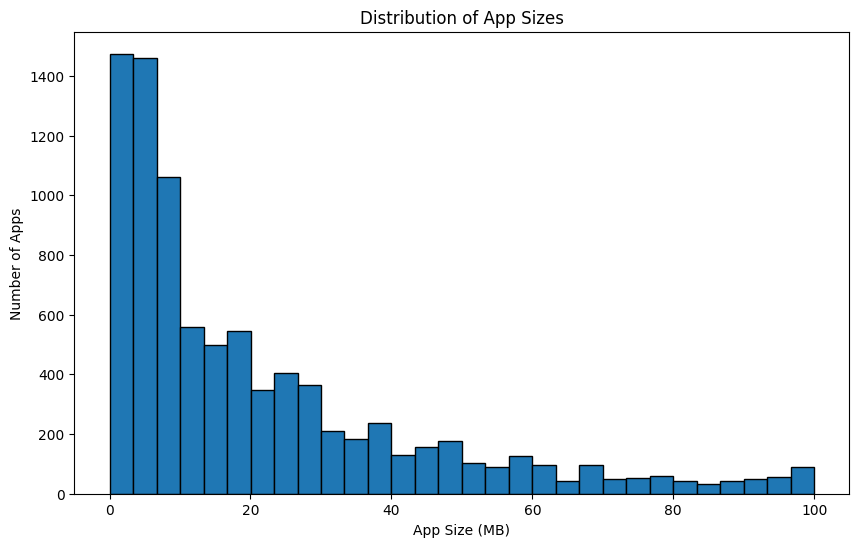

In [32]:
plt.figure(figsize=(10, 6))

plt.hist(df['Size_MB'].dropna(), bins=30, edgecolor='black')

plt.title('Distribution of App Sizes')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Apps')

plt.show()

Question 4

In [34]:
app_type_counts = df['Type'].value_counts()

print(app_type_counts)

Type
Free       9591
Paid        765
Unknown       1
0             1
Name: count, dtype: int64


Question 5

In [35]:
content_rating_counts = df['Content Rating'].value_counts()

print("Content Rating Distribution:")
print(content_rating_counts)

most_common_rating = content_rating_counts.idxmax()
most_common_count = content_rating_counts.max()

print(f"\nMost common content rating: {most_common_rating}")
print(f"Number of apps: {most_common_count}")

Content Rating Distribution:
Content Rating
Everyone           8382
Teen               1146
Mature 17+          447
Everyone 10+        377
Adults only 18+       3
Unrated               2
Unknown               1
Name: count, dtype: int64

Most common content rating: Everyone
Number of apps: 8382


Question 6

In [36]:
top_5_apps = (
    df[['App', 'Installs']]
    .sort_values(by='Installs', ascending=False)
    .head(5)
)

print("Top 5 Most Installed Apps:")
display(top_5_apps)

Top 5 Most Installed Apps:


,App,Installs
9990,Life Made WI-Fi Touchscreen Photo Frame,Free
3664,Twitter,"500,000,000+"
314,imo free video calls and chat,"500,000,000+"
2849,Gboard - the Google Keyboard,"500,000,000+"
3558,Clean Master- Space Cleaner & Antivirus,"500,000,000+"


Question 7

In [37]:
apps_rating_4_or_higher = df[df['Rating'] >= 4.0]

count_rating_4_or_higher = apps_rating_4_or_higher.shape[0]

print(f"Number of apps with rating 4.0 or higher: {count_rating_4_or_higher}")

Number of apps with rating 4.0 or higher: 6948


Question 8

In [38]:
average_reviews_by_type = df.groupby('Type')['Reviews'].mean()

print("Average Reviews by App Type:")
print(average_reviews_by_type)

Average Reviews by App Type:
Type
0                    NaN
Free       437373.593056
Paid        11900.550327
Unknown         0.000000
Name: Reviews, dtype: float64


Question 9

In [39]:
average_size_by_category = (
    df.groupby('Category')['Size_MB']
    .mean()
    .sort_values(ascending=False)
)

print("Average App Size by Category:")
display(average_size_by_category)

Average App Size by Category:


Category
GAME                   44.126816
FAMILY                 27.930205
TRAVEL_AND_LOCAL       24.515960
SPORTS                 24.180992
ENTERTAINMENT          22.638806
PARENTING              22.512963
FOOD_AND_DRINK         22.056122
HEALTH_AND_FITNESS     21.642819
EDUCATION              20.076632
AUTO_AND_VEHICLES      20.036807
MEDICAL                19.383059
FINANCE                17.937470
SOCIAL                 16.875621
PHOTOGRAPHY            16.831950
MAPS_AND_NAVIGATION    16.614368
VIDEO_PLAYERS          16.084441
HOUSE_AND_HOME         15.970010
SHOPPING               15.897718
DATING                 15.825941
LIFESTYLE              14.856415
EVENTS                 13.963617
BUSINESS               13.912536
BEAUTY                 13.795745
COMICS                 13.484869
BOOKS_AND_REFERENCE    13.189322
WEATHER                13.124006
PRODUCTIVITY           12.871599
NEWS_AND_MAGAZINES     12.646415
ART_AND_DESIGN         12.370968
COMMUNICATION          11.657320
P

Question 10

In [40]:
apps_updated_2018 = df[df['Last Updated'].dt.year == 2018]

count_updated_2018 = apps_updated_2018.shape[0]

print(f"Number of apps last updated in 2018: {count_updated_2018}")

Number of apps last updated in 2018: 6934


Medium Level 

Question 1

In [44]:
correlation = df['Installs'].corr(df['Rating'])

print(f"Correlation between Installs and Rating: {correlation:.4f}")

Correlation between Installs and Rating: 0.0509


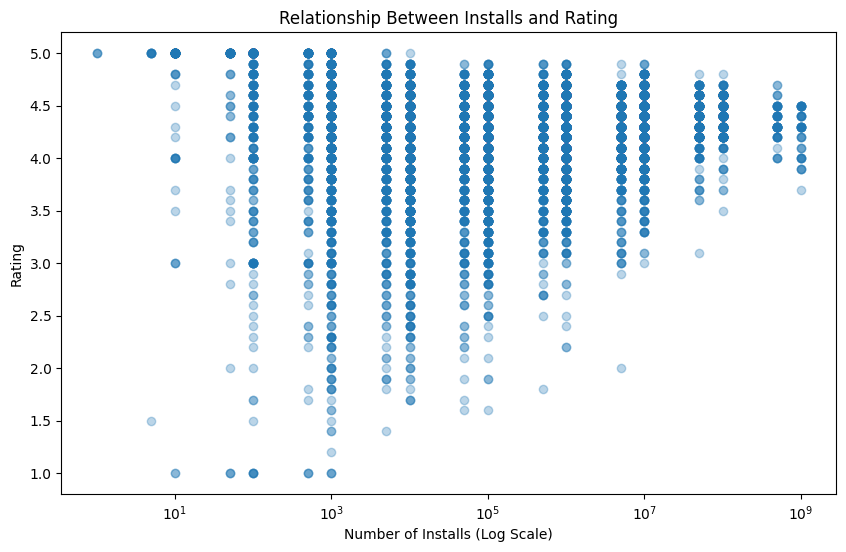

In [62]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Installs'],
    df['Rating'],
    alpha=0.3
)

plt.xscale('log')

plt.title('Relationship Between Installs and Rating')
plt.xlabel('Number of Installs (Log Scale)')
plt.ylabel('Rating')

plt.show()

Question 2

In [45]:
average_rating_by_category = (
    df.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Category:")
display(average_rating_by_category)

Average Rating by Category:


Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.375969
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.347458
PERSONALIZATION         4.333871
PARENTING               4.300000
GAME                    4.281285
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.261450
SOCIAL                  4.254918
SHOPPING                4.251485
WEATHER                 4.244000
SPORTS                  4.225175
PRODUCTIVITY            4.201796
FAMILY                  4.191153
AUTO_AND_VEHICLES       4.190411
PHOTOGRAPHY             4.182895
MEDICAL                 4.182450
LIBRARIES_AND_DEMO      4.178462
HOUSE_AND_HOME          4.164706
FOOD_AND_DRINK          4.164151
COMICS                  4.155172
COMMUNICATION           4.151466
ENTERTAINMENT           4.136036
NEWS_AND_MAGAZINES      4.128505
FINANCE                 4.127445
BUSINESS                4.102593
LIFESTYLE               4.096066
TRAVEL_AND_LOCAL        4.094146
V

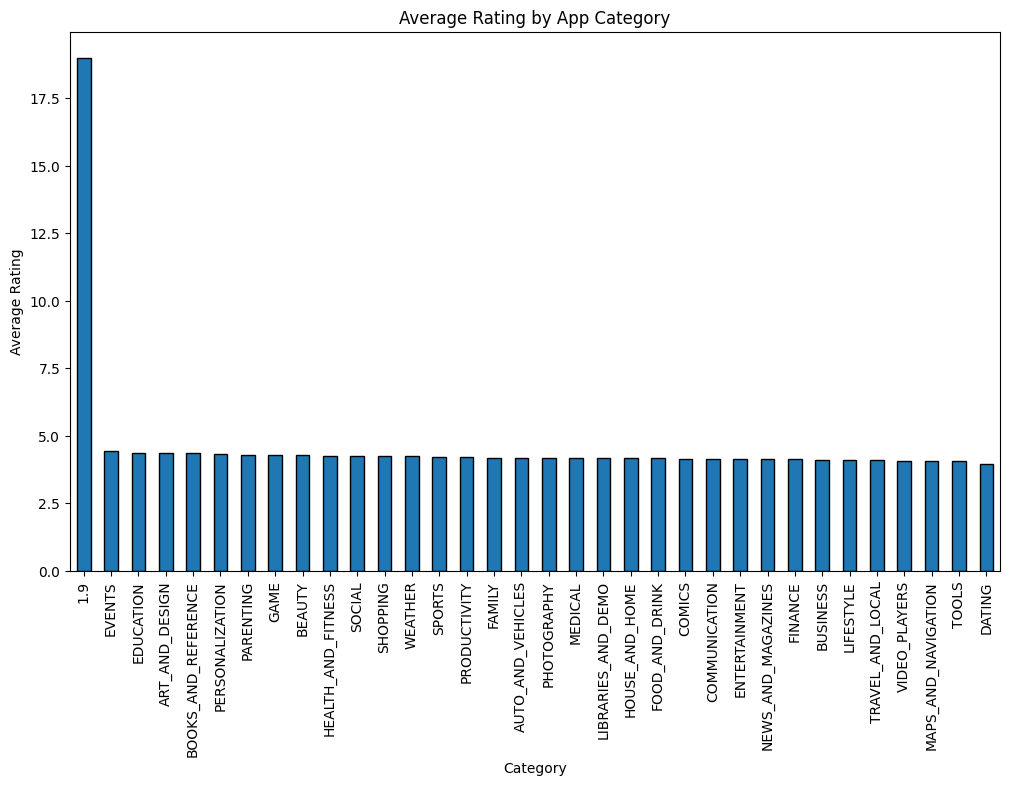

In [46]:
plt.figure(figsize=(12, 7))

average_rating_by_category.plot(kind='bar', edgecolor='black')

plt.title('Average Rating by App Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)
plt.show()

Question 3

In [47]:
paid_apps = df[df['Type'] == 'Paid'].copy()

# Calculate average rating for each price
average_rating_by_price = (
    paid_apps.groupby('Price')['Rating']
    .mean()
    .sort_index()
)

print("Average Rating by Price for Paid Apps:")
display(average_rating_by_price)

Average Rating by Price for Paid Apps:


Price
$0.99     4.298095
$1.00     4.450000
$1.04          NaN
$1.20     4.200000
$1.26          NaN
            ...   
$8.49     3.700000
$8.99     3.725000
$89.99         NaN
$9.00     4.200000
$9.99     4.192857
Name: Rating, Length: 91, dtype: float64

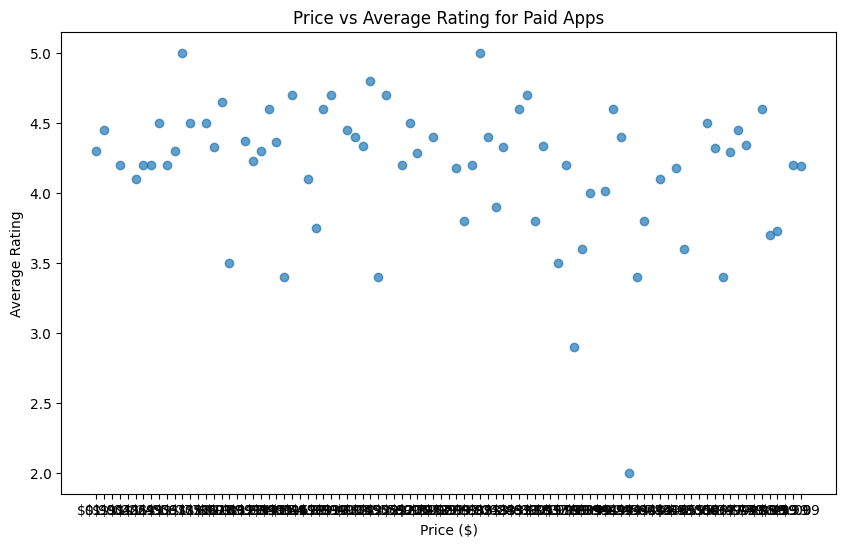

In [61]:
plt.figure(figsize=(10, 6))

plt.scatter(
    average_rating_by_price.index,
    average_rating_by_price.values,
    alpha=0.7
)

plt.title('Price vs Average Rating for Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Average Rating')

plt.show()

Question 4

<Figure size 1000x600 with 0 Axes>

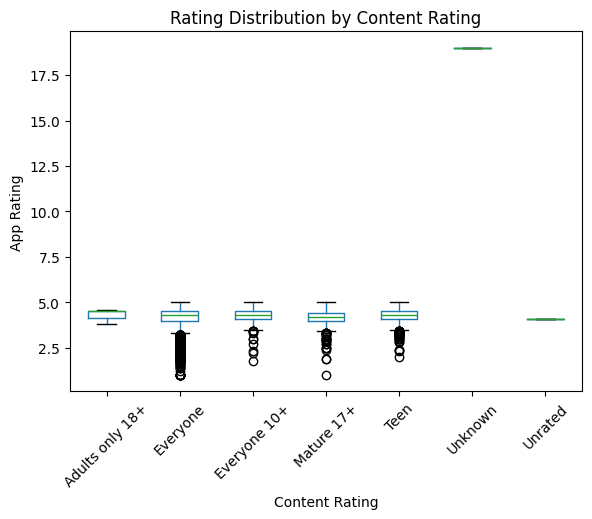

In [48]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column='Rating',
    by='Content Rating',
    grid=False
)

plt.title('Rating Distribution by Content Rating')
plt.suptitle('')
plt.xlabel('Content Rating')
plt.ylabel('App Rating')
plt.xticks(rotation=45)

plt.show()

Question 5

In [49]:
apps_over_1m = df[df['Installs'] > 1_000_000]

# Count apps in each genre
genre_counts = (
    apps_over_1m['Genres']
    .value_counts()
    .sort_values(ascending=False)
)

print("Genres with the Most Apps Over 1 Million Installs:")
display(genre_counts)

Genres with the Most Apps Over 1 Million Installs:


Genres
Tools                               187
Action                              182
Photography                         161
Communication                       146
Productivity                        124
                                   ... 
Parenting                             1
Card;Action & Adventure               1
Entertainment;Action & Adventure      1
Sports;Action & Adventure             1
Role Playing;Brain Games              1
Name: count, Length: 88, dtype: int64

Question 6

In [50]:
# Find the latest update date in the dataset
latest_update = df['Last Updated'].max()

# Calculate the number of days since each app's last update
df['Days_Since_Last_Update'] = (
    latest_update - df['Last Updated']
).dt.days

# Calculate the average number of days
average_days_since_update = df['Days_Since_Last_Update'].mean()

print(f"Latest update date in dataset: {latest_update.date()}")
print(f"Average days since last update: {average_days_since_update:.2f} days")
print(f"Average months since last update: {average_days_since_update / 30.44:.2f} months")

Latest update date in dataset: 2018-08-08
Average days since last update: 266.61 days
Average months since last update: 8.76 months


Question 7

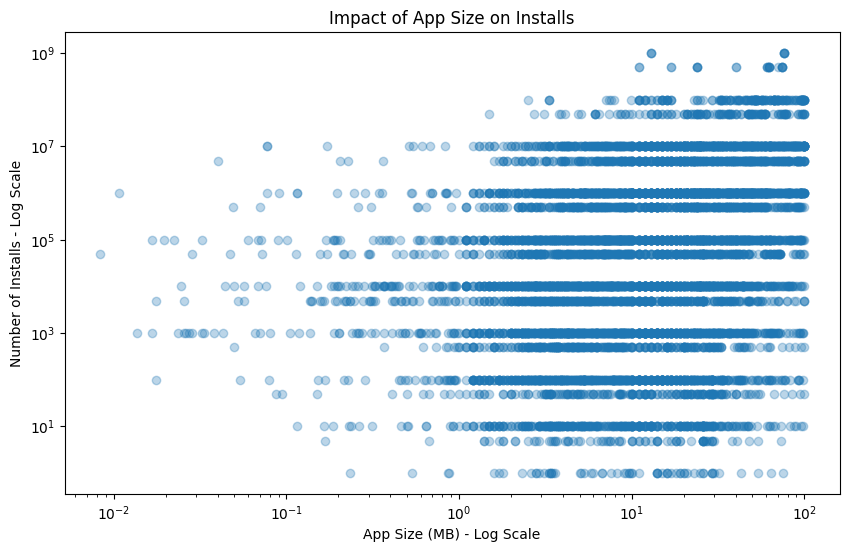

In [51]:
# Remove rows where Size or Installs is missing
size_install_data = df[['Size_MB', 'Installs']].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    size_install_data['Size_MB'],
    size_install_data['Installs'],
    alpha=0.3
)

plt.xscale('log')
plt.yscale('log')

plt.title('Impact of App Size on Installs')
plt.xlabel('App Size (MB) - Log Scale')
plt.ylabel('Number of Installs - Log Scale')

plt.show()

In [52]:
correlation_size_installs = (
    size_install_data['Size_MB']
    .corr(size_install_data['Installs'])
)

print(f"Correlation between App Size and Installs: {correlation_size_installs:.4f}")

Correlation between App Size and Installs: 0.1689


Question 8

In [53]:
top_reviewed_apps = (
    df[['App', 'Reviews', 'Rating']]
    .sort_values(by='Reviews', ascending=False)
    .head(10)
)

print("Top 10 Apps by Number of Reviews:")
display(top_reviewed_apps)

Top 10 Apps by Number of Reviews:


,App,Reviews,Rating
2246,Facebook,78158306.0,4.1
3498,Facebook,78128208.0,4.1
303,WhatsApp Messenger,69119316.0,4.4
3459,WhatsApp Messenger,69109672.0,4.4
2305,Instagram,66577446.0,4.5
2247,Instagram,66577313.0,4.5
3464,Instagram,66509917.0,4.5
348,Messenger – Text and Video Chat for Free,56646578.0,4.0
302,Messenger – Text and Video Chat for Free,56642847.0,4.0
1662,Clash of Clans,44893888.0,4.6


Question 9

In [55]:
content_rating_type = pd.crosstab(
    df['Content Rating'],
    df['Type']
)

print("Content Rating Distribution: Free vs Paid Apps")
display(content_rating_type)

Content Rating Distribution: Free vs Paid Apps


Type,0,Free,Paid,Unknown
Content Rating,,,,
Adults only 18+,0,3,0,0
Everyone,0,7720,662,0
Everyone 10+,0,344,32,1
Mature 17+,0,428,19,0
Teen,0,1094,52,0
Unknown,1,0,0,0
Unrated,0,2,0,0


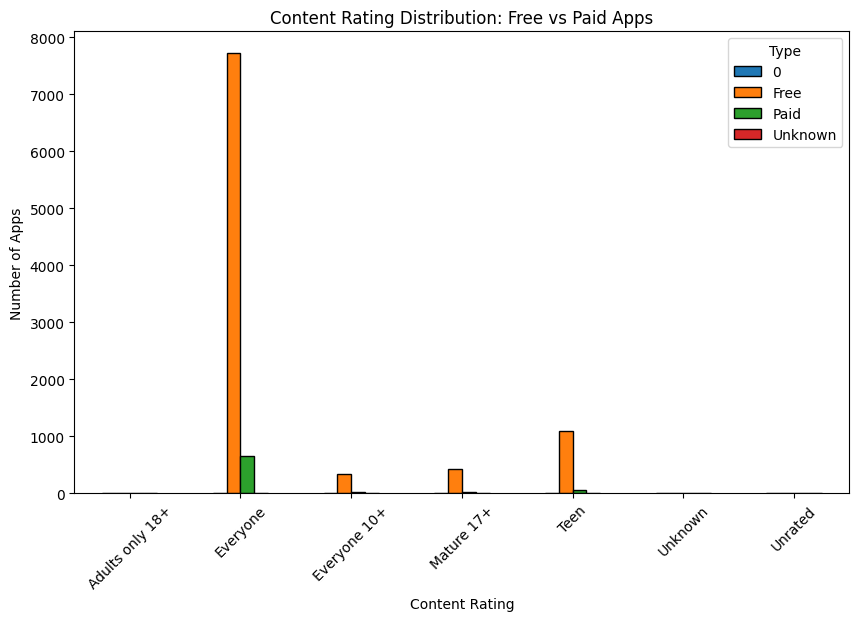

In [60]:
content_rating_type.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Content Rating Distribution: Free vs Paid Apps')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

plt.show()

Question 10

In [56]:
top_5_categories = (
    df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 Categories by Total Installs:")
display(top_5_categories)

Top 5 Categories by Total Installs:


Category
GAME             3.154402e+10
COMMUNICATION    2.415228e+10
SOCIAL           1.251387e+10
PRODUCTIVITY     1.246309e+10
TOOLS            1.145277e+10
Name: Installs, dtype: float64

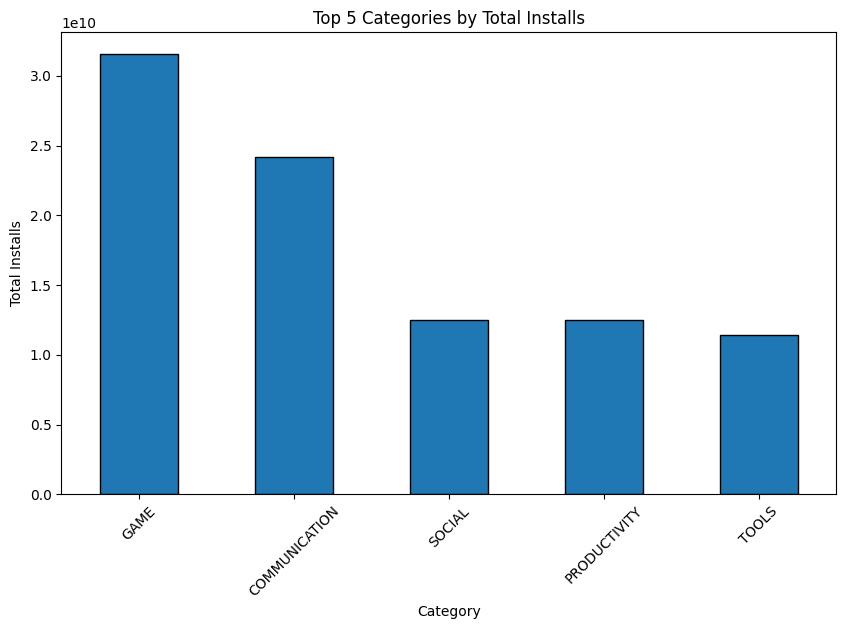

In [59]:
plt.figure(figsize=(10, 6))

top_5_categories.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Top 5 Categories by Total Installs')
plt.xlabel('Category')
plt.ylabel('Total Installs')
plt.xticks(rotation=45)

plt.show()

Advance Level****

Question 1

In [57]:
rated_apps = df[df['Reviews'] >= 100].copy()

# Find the top 10 highest-rated apps
top_10_rated_apps = (
    rated_apps[['App', 'Rating', 'Reviews', 'Installs']]
    .sort_values(
        by=['Rating', 'Reviews'],
        ascending=[False, False]
    )
    .head(10)
)

print("Top 10 Highest-Rated Apps:")
display(top_10_rated_apps)

Top 10 Highest-Rated Apps:


,App,Rating,Reviews,Installs
9875,Ríos de Fe,5.0,141.0,1000.0
9819,"FD Calculator (EMI, SIP, RD & Loan Eligilibility)",5.0,104.0,1000.0
7587,Oración CX,5.0,103.0,5000.0
6357,Barisal University App-BU Face,5.0,100.0,1000.0
9144,JW Library,4.9,922752.0,10000000.0
1103,Six Pack in 30 Days - Abs Workout,4.9,272337.0,10000000.0
4399,Six Pack in 30 Days - Abs Workout,4.9,272172.0,10000000.0
79,Tickets + PDA 2018 Exam,4.9,197136.0,1000000.0
628,"Learn Japanese, Korean, Chinese Offline & Free",4.9,133136.0,1000000.0
2086,Period Tracker,4.9,100082.0,1000000.0


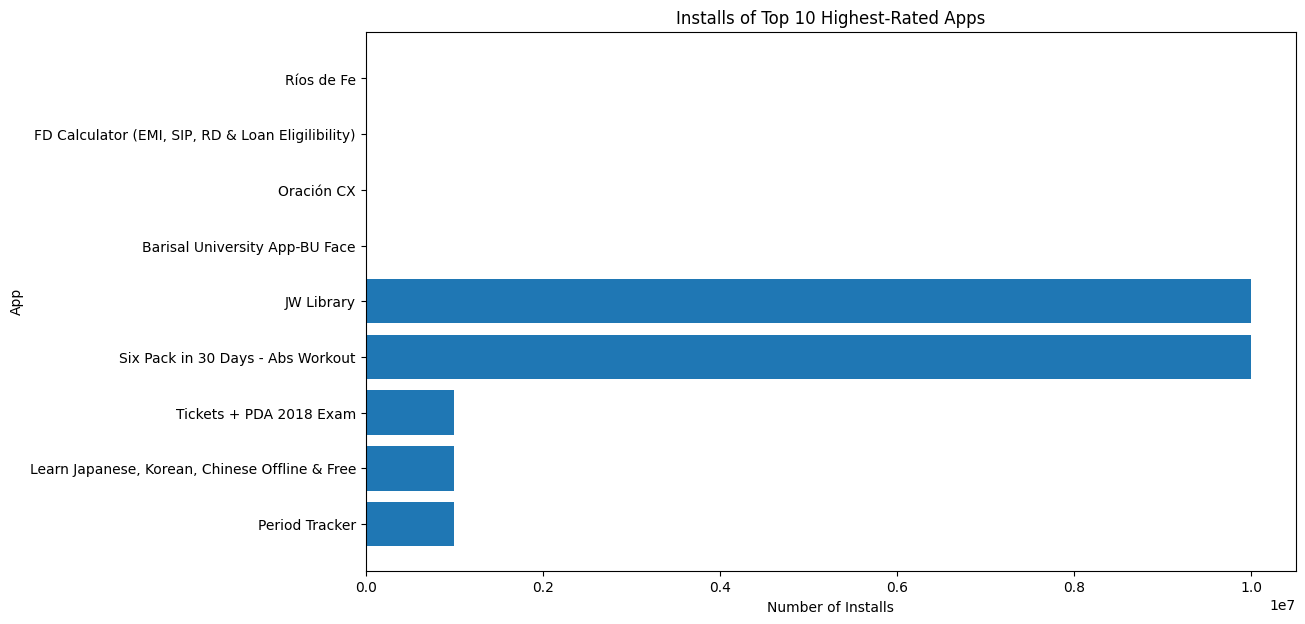

In [58]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_10_rated_apps['App'],
    top_10_rated_apps['Installs']
)

plt.title('Installs of Top 10 Highest-Rated Apps')
plt.xlabel('Number of Installs')
plt.ylabel('App')
plt.gca().invert_yaxis()

plt.show()

Question 2

In [63]:
#Yearly trend
df['Update Year'] = df['Last Updated'].dt.year

yearly_updates = df['Update Year'].value_counts().sort_index()

print("Number of App Updates by Year:")
display(yearly_updates)

Number of App Updates by Year:


Update Year
2010.0       1
2011.0      15
2012.0      26
2013.0     108
2014.0     204
2015.0     454
2016.0     789
2017.0    1826
2018.0    6934
Name: count, dtype: int64

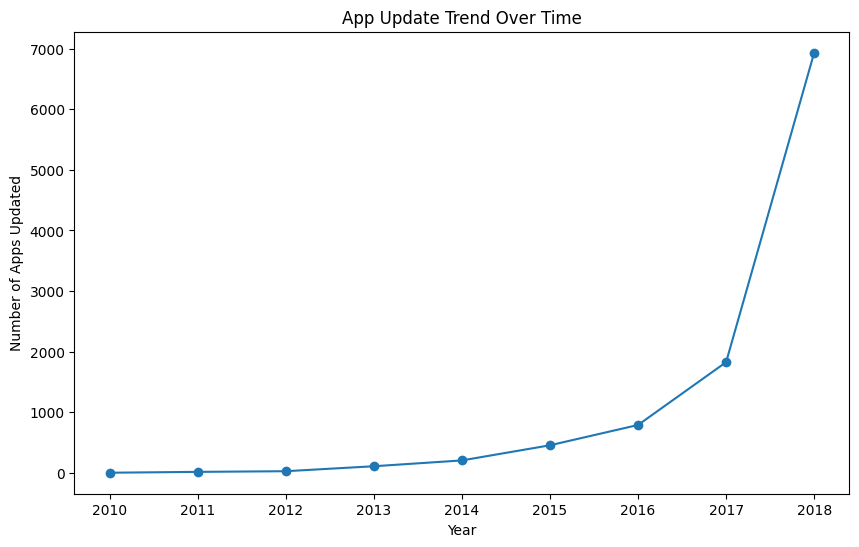

In [64]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_updates.index,
    yearly_updates.values,
    marker='o'
)

plt.title('App Update Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Apps Updated')

plt.show()

In [65]:
#Monthly Pattern
df['Update Month'] = df['Last Updated'].dt.month

monthly_updates = df['Update Month'].value_counts().sort_index()

print("Number of App Updates by Month:")
display(monthly_updates)

Number of App Updates by Month:


Update Month
1.0      480
2.0      527
3.0      656
4.0      600
5.0      962
6.0     1226
7.0     2950
8.0     1466
9.0      308
10.0     387
11.0     374
12.0     421
Name: count, dtype: int64

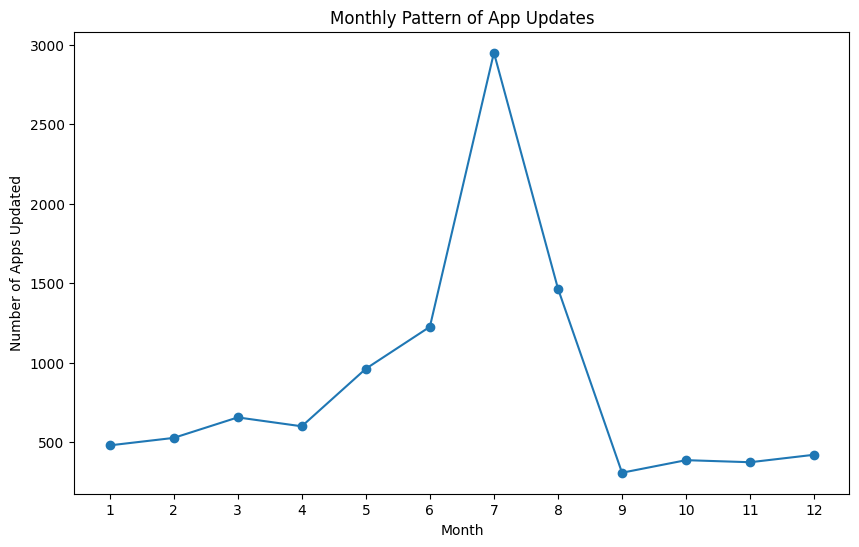

In [66]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_updates.index,
    monthly_updates.values,
    marker='o'
)

plt.title('Monthly Pattern of App Updates')
plt.xlabel('Month')
plt.ylabel('Number of Apps Updated')
plt.xticks(range(1, 13))

plt.show()

Question 3

In [67]:
# Create install bins
bins = [
    0,10_000,100_000,1_000_000,10_000_000,100_000_000,
    float('inf')
]

labels = [
    '0–10K','10K–100K','100K–1M','1M–10M','10M–100M',
    '100M+'
]

df['Install Range'] = pd.cut(
    df['Installs'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate average rating for each install range
avg_rating_by_install_range = (
    df.groupby('Install Range', observed=False)['Rating']
    .mean()
)

print("Average Rating by Install Range:")
display(avg_rating_by_install_range)

Average Rating by Install Range:


Install Range
0–10K       4.112427
10K–100K    4.094593
100K–1M     4.207043
1M–10M      4.285675
10M–100M    4.382995
100M+       4.309091
Name: Rating, dtype: float64

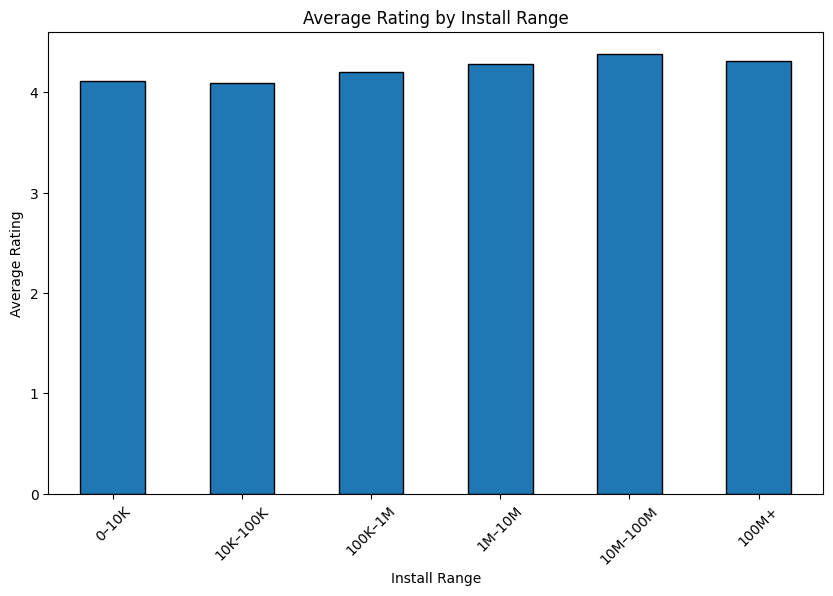

In [68]:
plt.figure(figsize=(10, 6))

avg_rating_by_install_range.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Rating by Install Range')
plt.xlabel('Install Range')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.show()

Question 4

In [69]:
# Create rating based sentiment categories
def classify_rating(rating):
    if pd.isna(rating):
        return 'No Rating'
    elif rating >= 4:
        return 'Positive'
    elif rating >= 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Rating Sentiment'] = df['Rating'].apply(classify_rating)

# Count each rating category
rating_sentiment_counts = df['Rating Sentiment'].value_counts()

print("Rating-Based User Feedback:")
display(rating_sentiment_counts)

Rating-Based User Feedback:


Rating Sentiment
Positive     6948
Neutral      1665
No Rating    1465
Negative      280
Name: count, dtype: int64

In [70]:
#Calculate percentage 
rating_sentiment_percentage = (
    df['Rating Sentiment']
    .value_counts(normalize=True)
    * 100
)

print("Rating-Based User Feedback (%):")
display(rating_sentiment_percentage.round(2))

Rating-Based User Feedback (%):


Rating Sentiment
Positive     67.08
Neutral      16.07
No Rating    14.14
Negative      2.70
Name: proportion, dtype: float64

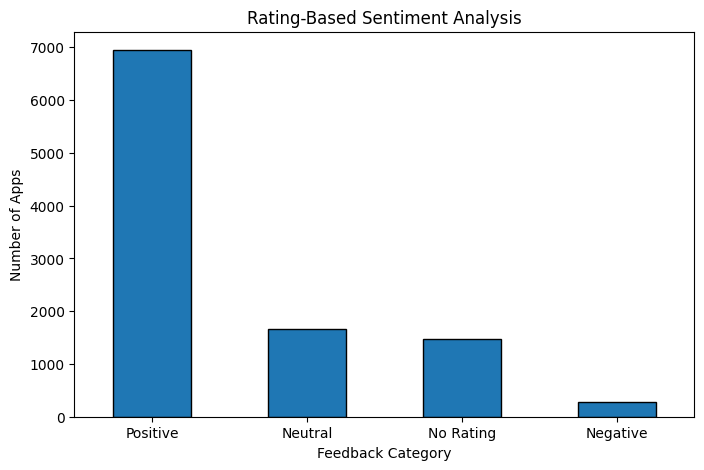

In [72]:
plt.figure(figsize=(8, 5))

rating_sentiment_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Rating-Based Sentiment Analysis')
plt.xlabel('Feedback Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)

plt.show()

Question 5

In [73]:
# Calculate mean and median rating for each genre
genre_rating_analysis = (
    df.groupby('Genres')['Rating']
    .agg(['mean', 'median', 'count'])
    .sort_values(by='mean', ascending=False)
)

print("Genre-wise Rating Analysis:")
display(genre_rating_analysis)

Genre-wise Rating Analysis:


,mean,median,count
Genres,,,
"February 11, 2018",19.0,19.0,1
Board;Pretend Play,4.8,4.8,1
Comics;Creativity,4.8,4.8,1
Health & Fitness;Education,4.7,4.7,1
Puzzle;Education,4.6,4.6,1
...,...,...,...
Parenting;Brain Games,3.8,3.8,1
Art & Design;Action & Adventure,NaN,NaN,0
Books & Reference;Creativity,NaN,NaN,0


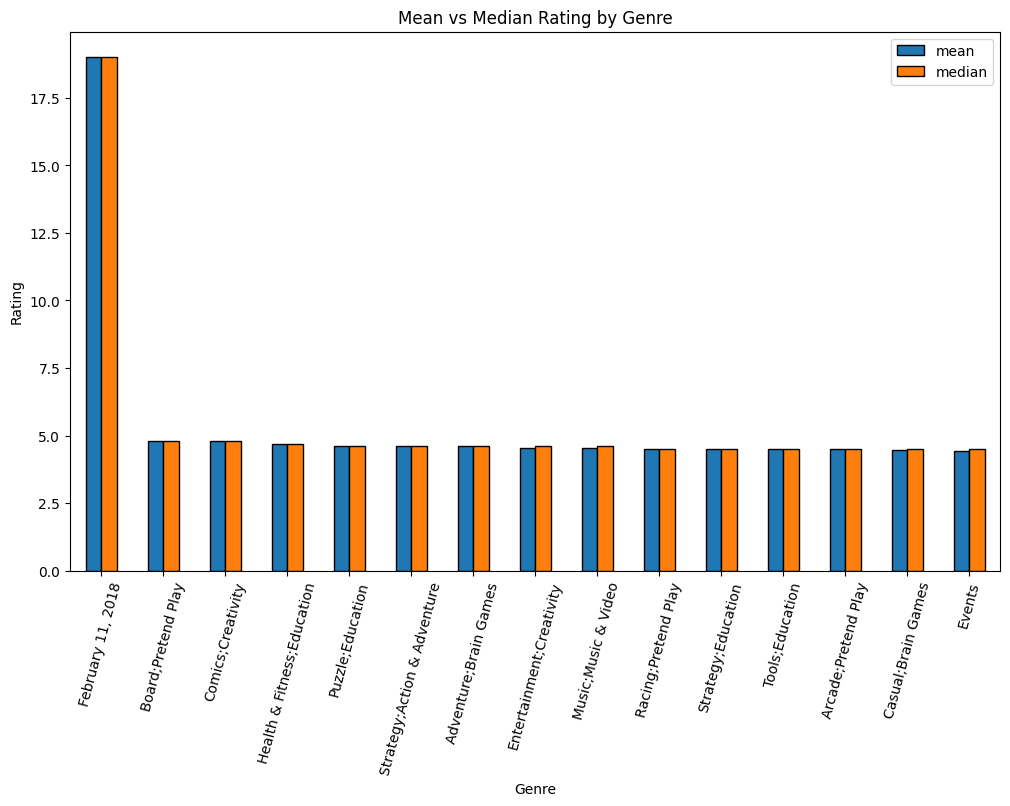

In [74]:
# Select top 15 genres by mean rating for easier visualization
top_genres = genre_rating_analysis.head(15)

top_genres[['mean', 'median']].plot(
    kind='bar',
    figsize=(12, 7),
    edgecolor='black'
)

plt.title('Mean vs Median Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.xticks(rotation=75)

plt.show()